In [4]:
# ============================================================
# STEP 1a: VERIFY WILLIE WEIGHTS EXIST AND ARE ACCESSIBLE
# ============================================================
# We do NOT download blindly. First, we inspect the repo to see
# what files are actually there — weight format, config, README.

from huggingface_hub import list_repo_files, hf_hub_download

# List all files in the WILLIE weights repository
# This tells us: is it .pt? .safetensors? ONNX? What config files?
repo_id = "QianGroup/willie-weights"

try:
    files = list_repo_files(repo_id)
    print("Files in WILLIE weights repo:")
    for f in files:
        print(f"  - {f}")
except Exception as e:
    print(f"ERROR: Could not access repo. Reason: {e}")
    print("Possible causes: repo is private, renamed, or deleted.")
    # DO NOT proceed if weights are inaccessible.
    # Fallback: check GitHub for inference code that points to correct path.

Files in WILLIE weights repo:
  - .gitattributes
  - README.md
  - assets/WILLIE Workflow.pdf
  - assets/WILLIE Workflow.png
  - base/willie_base_fold0_best.pt
  - base/willie_base_fold1_best.pt
  - base/willie_base_fold2_best.pt
  - base/willie_base_fold3_best.pt
  - base/willie_base_fold4_best.pt
  - decoders/medsam_decoder_best.pt
  - decoders/sam2_decoder_best.pt
  - mini/willie_mini_fold0_best.pt
  - mini/willie_mini_fold1_best.pt
  - mini/willie_mini_fold2_best.pt
  - mini/willie_mini_fold3_best.pt
  - mini/willie_mini_fold4_best.pt
  - xl/willie_xl_fold0_best.pt
  - xl/willie_xl_fold1_best.pt
  - xl/willie_xl_fold2_best.pt
  - xl/willie_xl_fold3_best.pt
  - xl/willie_xl_fold4_best.pt


In [7]:
from huggingface_hub import hf_hub_download, list_repo_files

files = list_repo_files(repo_id)

# Find any license-related files
license_files = [
    f for f in files
    if any(x in f.lower() for x in ["license", "copying"])
]

print("License-related files:", license_files)

# Inspect README license metadata
readme_path = hf_hub_download(
    repo_id=repo_id,
    filename="README.md"
)

with open(readme_path, encoding="utf-8") as f:
    for line in f:
        if "license:" in line.lower():
            print(line.strip())

License-related files: []


license: mit


In [9]:
import requests

url = "https://api.github.com/repos/Qian-Group-HRI/willie/contents"
r = requests.get(url)
r.raise_for_status()

for item in r.json():
    print(item["name"], item["type"])

.gitignore file
01_WILLIE_DataForge.ipynb file
02_WILLIE_DetectionEngine.ipynb file
03_WILLIE_Cls_Baselines.ipynb file
04_WILLIE_Seg_Baselines.ipynb file
05_WILLIE_SAM2_vs_MedSAM.ipynb file
06_WILLIE_MINI.ipynb file
07_WILLIE_BASE.ipynb file
08_WILLIE_XL.ipynb file
09_WILLIE_Scaling_Analysis.ipynb file
10_WILLIE_Cls_Comparison.ipynb file
11_WILLIE_Det_Comparison.ipynb file
Detection_Predictions dir
Figures dir
LICENSE file
Manifests_and_Splits dir
README.md file
SAM2_Generated_Masks dir
Tables dir
ablations dir
data dir
environment.txt file
verify_data.py file


In [10]:
import torch
from huggingface_hub import hf_hub_download

repo_id = "QianGroup/willie-weights"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Download an actual Mini checkpoint
weights_path = hf_hub_download(
    repo_id=repo_id,
    filename="mini/willie_mini_fold0_best.pt"
)

print("Checkpoint downloaded:", weights_path)

# Inspect checkpoint structure safely
checkpoint = torch.load(
    weights_path,
    map_location="cpu",
    weights_only=True
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", list(checkpoint.keys()))

    for key, value in checkpoint.items():
        if isinstance(value, dict):
            print(f"\n{key}:")
            for i, (name, tensor) in enumerate(value.items()):
                if i == 10:
                    break
                print(name, getattr(tensor, "shape", type(tensor)))
        elif isinstance(value, torch.Tensor):
            print(key, value.shape)

Device: cuda
Checkpoint downloaded: C:\Users\Lenovo\.cache\huggingface\hub\models--QianGroup--willie-weights\snapshots\2065b069cf9d407cbd1471b0b27cfc2bfc314d64\mini\willie_mini_fold0_best.pt


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([scalar])` or the `torch.serialization.safe_globals([scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weig

In [21]:
checkpoint = torch.load(
    weights_path,
    map_location="cpu",
    weights_only=False
)

In [24]:
import torch
from huggingface_hub import hf_hub_download

repo_id = "QianGroup/willie-weights"
weights_path = hf_hub_download(
    repo_id=repo_id,
    filename="mini/willie_mini_fold0_best.pt"
)

checkpoint = torch.load(
    weights_path,
    map_location="cpu",
    weights_only=False,   # <-- the fix
)

print("Type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Top-level keys:", list(checkpoint.keys()))
    sd = checkpoint.get("model_state_dict", checkpoint.get("state_dict", checkpoint))
    print("Total params:", len(sd))
    for i, (k, v) in enumerate(sd.items()):
        if i < 40:
            print(k, tuple(v.shape) if hasattr(v, 'shape') else v)

Type: <class 'dict'>
Top-level keys: ['model_state_dict', 'epoch', 'fold', 'metrics', 'config', 'optimizer_state_dict', 'scheduler_state_dict']
Total params: 380
encoder.backbone.cls_token (1, 1, 384)
encoder.backbone.pos_embed (1, 1370, 384)
encoder.backbone.mask_token (1, 384)
encoder.backbone.patch_embed.proj.weight (384, 3, 14, 14)
encoder.backbone.patch_embed.proj.bias (384,)
encoder.backbone.blocks.0.norm1.weight (384,)
encoder.backbone.blocks.0.norm1.bias (384,)
encoder.backbone.blocks.0.attn.qkv.weight (1152, 384)
encoder.backbone.blocks.0.attn.qkv.bias (1152,)
encoder.backbone.blocks.0.attn.proj.weight (384, 384)
encoder.backbone.blocks.0.attn.proj.bias (384,)
encoder.backbone.blocks.0.ls1.gamma (384,)
encoder.backbone.blocks.0.norm2.weight (384,)
encoder.backbone.blocks.0.norm2.bias (384,)
encoder.backbone.blocks.0.mlp.fc1.weight (1536, 384)
encoder.backbone.blocks.0.mlp.fc1.bias (1536,)
encoder.backbone.blocks.0.mlp.fc2.weight (384, 1536)
encoder.backbone.blocks.0.mlp.fc2.bi

In [25]:
import torch, json
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(
    repo_id="QianGroup/willie-weights",
    filename="mini/willie_mini_fold0_best.pt"
)
checkpoint = torch.load(weights_path, map_location="cpu", weights_only=False)

# Print the stored config — this may fully define the architecture
print(json.dumps(checkpoint["config"], indent=2, default=str))

# Then print ALL 380 keys (not just 40)
sd = checkpoint["model_state_dict"]
print(f"\nTotal keys: {len(sd)}\n")
for k, v in sd.items():
    print(k, tuple(v.shape) if hasattr(v, 'shape') else v)

{
  "name": "MINI",
  "backbone_name": "dinov2_vits14",
  "backbone_dim": 384,
  "backbone_layers": [
    2,
    5,
    8,
    11
  ],
  "img_size": 518,
  "patch_size": 14,
  "fpn_dim": 256,
  "fpn_levels": 4,
  "wa_csa_layers": 1,
  "wa_csa_heads": 8,
  "wa_csa_dropout": 0.1,
  "num_classes": 5,
  "num_experts": 2,
  "top_k_experts": 2,
  "cls_embed_dim": 128,
  "seg_out_channels": 1,
  "pscse_reduction": 16,
  "det_max_objects": 20,
  "freeze_backbone_epochs": 3
}

Total keys: 380

encoder.backbone.cls_token (1, 1, 384)
encoder.backbone.pos_embed (1, 1370, 384)
encoder.backbone.mask_token (1, 384)
encoder.backbone.patch_embed.proj.weight (384, 3, 14, 14)
encoder.backbone.patch_embed.proj.bias (384,)
encoder.backbone.blocks.0.norm1.weight (384,)
encoder.backbone.blocks.0.norm1.bias (384,)
encoder.backbone.blocks.0.attn.qkv.weight (1152, 384)
encoder.backbone.blocks.0.attn.qkv.bias (1152,)
encoder.backbone.blocks.0.attn.proj.weight (384, 384)
encoder.backbone.blocks.0.attn.proj.bias (

In [26]:
import torch
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(
    repo_id="QianGroup/willie-weights",
    filename="mini/willie_mini_fold0_best.pt"
)

checkpoint = torch.load(weights_path, map_location="cpu", weights_only=False)
sd = checkpoint["model_state_dict"]

# Print ALL keys
for k, v in sd.items():
    print(k, tuple(v.shape) if hasattr(v, 'shape') else v)

encoder.backbone.cls_token (1, 1, 384)
encoder.backbone.pos_embed (1, 1370, 384)
encoder.backbone.mask_token (1, 384)
encoder.backbone.patch_embed.proj.weight (384, 3, 14, 14)
encoder.backbone.patch_embed.proj.bias (384,)
encoder.backbone.blocks.0.norm1.weight (384,)
encoder.backbone.blocks.0.norm1.bias (384,)
encoder.backbone.blocks.0.attn.qkv.weight (1152, 384)
encoder.backbone.blocks.0.attn.qkv.bias (1152,)
encoder.backbone.blocks.0.attn.proj.weight (384, 384)
encoder.backbone.blocks.0.attn.proj.bias (384,)
encoder.backbone.blocks.0.ls1.gamma (384,)
encoder.backbone.blocks.0.norm2.weight (384,)
encoder.backbone.blocks.0.norm2.bias (384,)
encoder.backbone.blocks.0.mlp.fc1.weight (1536, 384)
encoder.backbone.blocks.0.mlp.fc1.bias (1536,)
encoder.backbone.blocks.0.mlp.fc2.weight (384, 1536)
encoder.backbone.blocks.0.mlp.fc2.bias (384,)
encoder.backbone.blocks.0.ls2.gamma (384,)
encoder.backbone.blocks.1.norm1.weight (384,)
encoder.backbone.blocks.1.norm1.bias (384,)
encoder.backbone.bl

In [27]:
# After loading sd
from collections import defaultdict

groups = defaultdict(list)
for k in sd.keys():
    # Group by top-level module (before first dot)
    top = k.split(".")[0]
    groups[top].append(k)

for group, keys in groups.items():
    print(f"\n{group}: {len(keys)} keys")
    for k in keys[:5]:
        print(f"  {k}")


encoder: 175 keys
  encoder.backbone.cls_token
  encoder.backbone.pos_embed
  encoder.backbone.mask_token
  encoder.backbone.patch_embed.proj.weight
  encoder.backbone.patch_embed.proj.bias

fpn: 24 keys
  fpn.laterals.0.0.weight
  fpn.laterals.0.1.weight
  fpn.laterals.0.1.bias
  fpn.laterals.1.0.weight
  fpn.laterals.1.1.weight

wa_csa: 66 keys
  wa_csa.layers.0.0.alpha_f
  wa_csa.layers.0.0.alpha_c
  wa_csa.layers.0.0.q_f.weight
  wa_csa.layers.0.0.k_c.weight
  wa_csa.layers.0.0.v_c.weight

cls_decoder: 19 keys
  cls_decoder.scale_attn.0.weight
  cls_decoder.scale_attn.0.bias
  cls_decoder.pre.0.weight
  cls_decoder.pre.0.bias
  cls_decoder.pre.1.weight

seg_decoder: 81 keys
  seg_decoder.films.0.gamma.0.weight
  seg_decoder.films.0.gamma.0.bias
  seg_decoder.films.0.beta.weight
  seg_decoder.films.0.beta.bias
  seg_decoder.films.1.gamma.0.weight

det_decoder: 15 keys
  det_decoder.level_w
  det_decoder.shared.0.weight
  det_decoder.shared.1.weight
  det_decoder.shared.1.bias
  det

In [29]:
!git ls-remote https://github.com/Qian-Group-HRI/Willie.git

221f2e7ef470810422436c12730834c82e9bdc8f	HEAD
221f2e7ef470810422436c12730834c82e9bdc8f	refs/heads/main


In [30]:
class WILLIEModel(nn.Module):
    """
    DINOv2 → FPN → WA-CSA → [CLS(MoE) + SEG(P-scSE+FiLM) + DET]
    WTCS bridge: cls wound_embed → FiLM conditioning on seg decoder.
    """
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.encoder = DINOv2MultiScale(cfg)
        self.fpn = FeaturePyramidNeck(cfg)
        self.wa_csa = WA_CSA_Stack(cfg)
        self.cls_decoder = ClassificationDecoder(cfg)
        self.seg_decoder = SegmentationDecoder(cfg)
        self.det_decoder = DetectionDecoder(cfg)

In [31]:
def forward(self, x, target_seg_size=None):
    pyr = self.wa_csa(self.fpn(self.encoder(x)))
    logits, embed = self.cls_decoder(pyr)
    seg = self.seg_decoder(pyr, embed, target_seg_size)
    det = self.det_decoder(pyr)
    return {
        "cls_logits": logits,           # [B, 5]
        "wound_embed": embed,           # [B, 128]  ← FiLM conditioning
        "seg_mask": seg,                # [B, 1, 518, 518]
        "det_objectness": det["objectness"],  # [B, 1, 37, 37]
        "det_bbox": det["bbox"],        # [B, 4, 37, 37]
        "det_cls": det["det_cls"],      # [B, 5, 37, 37]
    }

In [32]:
def forward(self, x):
    self.features.clear()
    if x.shape[-1] != self.cfg.img_size:
        x = F.interpolate(x, size=self.cfg.img_size, mode="bilinear", align_corners=False)
    self.backbone(x)

In [34]:
import os
import subprocess
import nbformat
from pathlib import Path

# --- Clone the repo if not present ---
REPO_DIR = "Willie"
if not os.path.exists(REPO_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/Qian-Group-HRI/Willie.git"],
        check=True
    )
    print("Cloned repo.")
else:
    print("Repo already present.")

# --- Pin to the commit we verified ---
subprocess.run(
    ["git", "-C", REPO_DIR, "checkout", "221f2e7ef470810422436c12730834c82e9bdc8f"],
    check=False  # don't fail if already on it
)

# --- Find the MINI notebook ---
nb_path = None
for p in Path(REPO_DIR).rglob("*.ipynb"):
    if "mini" in p.name.lower():
        nb_path = str(p)
        break

if nb_path is None:
    # Fallback: list all notebooks so we can see what's there
    print("No *mini*.ipynb found. All notebooks in repo:")
    for p in Path(REPO_DIR).rglob("*.ipynb"):
        print(f"  {p}")
    raise SystemExit("Specify the notebook path manually.")

print(f"Using notebook: {nb_path}")

# --- Extract all code cells into one .py file ---
nb = nbformat.read(nb_path, as_version=4)

lines = []
lines.append("# Auto-extracted from WILLIE notebook.")
lines.append("# Source: Qian-Group-HRI/Willie @ 221f2e7")
lines.append("# Do not edit by hand — re-run the extractor if needed.\n")

for i, cell in enumerate(nb.cells):
    if cell.cell_type != "code":
        continue
    src = cell.source
    # Skip shell-only lines
    if src.strip().startswith("!"):
        continue
    lines.append(f"# ==== Cell {i} ====")
    lines.append(src)
    lines.append("")

with open("willie_model.py", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("✅ Wrote willie_model.py")

# --- Show what classes and functions it defines ---
import re
with open("willie_model.py") as f:
    content = f.read()

classes = re.findall(r"^class (\w+)", content, re.MULTILINE)
funcs = re.findall(r"^def (\w+)", content, re.MULTILINE)

print(f"\nClasses found ({len(classes)}):")
for c in classes:
    print(f"  class {c}")

print(f"\nTop-level functions found ({len(funcs)}):")
for fn in funcs:
    print(f"  def {fn}()")

Cloned repo.
Using notebook: Willie\06_WILLIE_MINI.ipynb
✅ Wrote willie_model.py


UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 4234: character maps to <undefined>

In [36]:
import ast
import os
import subprocess
import nbformat
from pathlib import Path

# --- Clone if missing ---
REPO_DIR = "Willie"
if not os.path.exists(REPO_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/Qian-Group-HRI/Willie.git"],
        check=True
    )

# --- Pin to verified commit ---
subprocess.run(
    ["git", "-C", REPO_DIR, "checkout", "221f2e7ef470810422436c12730834c82e9bdc8f"],
    check=False
)

# --- Find MINI notebook ---
nb_path = None
for p in Path(REPO_DIR).rglob("*.ipynb"):
    if "mini" in p.name.lower():
        nb_path = str(p)
        break

assert nb_path, "No *mini*.ipynb found"
print(f"Using notebook: {nb_path}")

nb = nbformat.read(nb_path, as_version=4)

# --- Parse each cell, keep only defs/imports/simple constants ---
imports = []
defs = []
constants = []

def is_simple_constant(node):
    """Module-level NAME = <literal or simple expr>"""
    if not isinstance(node, ast.Assign):
        return False
    # Only allow single-name targets (UPPER or CamelCase or plain)
    if len(node.targets) != 1 or not isinstance(node.targets[0], ast.Name):
        return False
    # Reject calls (they might do I/O)
    for sub in ast.walk(node.value):
        if isinstance(sub, ast.Call):
            return False
    return True

for cell in nb.cells:
    if cell.cell_type != "code":
        continue
    src = cell.source
    if not src.strip():
        continue
    # Skip shell magics
    src = "\n".join(
        line for line in src.splitlines()
        if not line.strip().startswith("!")
    )
    if not src.strip():
        continue
    try:
        tree = ast.parse(src)
    except SyntaxError:
        continue

    for node in tree.body:
        if isinstance(node, (ast.Import, ast.ImportFrom)):
            imports.append(ast.unparse(node))
        elif isinstance(node, (ast.ClassDef, ast.FunctionDef, ast.AsyncFunctionDef)):
            defs.append(ast.unparse(node))
        elif is_simple_constant(node):
            constants.append(ast.unparse(node))

# --- Deduplicate imports ---
seen = set()
uniq_imports = []
for imp in imports:
    if imp not in seen:
        seen.add(imp)
        uniq_imports.append(imp)

# --- Write out ---
header = (
    "# Auto-extracted from WILLIE notebook (classes and functions only).\n"
    "# Source: Qian-Group-HRI/Willie @ 221f2e7\n"
    "# Top-level execution code was stripped by the AST extractor.\n"
)

with open("willie_model.py", "w", encoding="utf-8") as f:
    f.write(header + "\n")
    f.write("\n".join(uniq_imports) + "\n\n")
    if constants:
        f.write("# --- Module-level constants ---\n")
        f.write("\n".join(constants) + "\n\n")
    f.write("\n\n".join(defs))

print("✅ Wrote willie_model.py")

# --- Report what we extracted ---
with open("willie_model.py", encoding="utf-8") as f:
    content = f.read()

import re
classes = re.findall(r"^class (\w+)", content, re.MULTILINE)
funcs = re.findall(r"^def (\w+)", content, re.MULTILINE)

print(f"\nClasses extracted ({len(classes)}):")
for c in classes:
    print(f"  class {c}")

print(f"\nFunctions extracted ({len(funcs)}):")
for fn in funcs:
    print(f"  def {fn}()")

Using notebook: Willie\06_WILLIE_MINI.ipynb
✅ Wrote willie_model.py

Classes extracted (22):
  class ModelConfig
  class DINOv2MultiScale
  class FeaturePyramidNeck
  class WoundAwareCrossScaleAttention
  class WA_CSA_Stack
  class Expert
  class TopKRouter
  class ClassificationDecoder
  class ChannelSE
  class SpatialSE
  class ParallelScSE
  class FiLMConditioner
  class PscSEDecoderStage
  class SegmentationDecoder
  class DetectionDecoder
  class WILLIEModel
  class CheckpointManager
  class WoundMultiTaskDataset
  class DiceLoss
  class MultiTaskLoss
  class MultiTaskLossSafe
  class TTADataset

Functions extracted (26):
  def get_model_config()
  def build_and_verify()
  def create_5fold_splits()
  def get_train_transforms()
  def get_val_transforms()
  def get_tta_transforms()
  def parse_yolo_bbox()
  def mask_to_bboxes()
  def collate_multitask()
  def compute_combined_metric()
  def get_fold_dataloaders()
  def get_test_dataloader()
  def _atomic_save()
  def _load_progress(

In [39]:
%pip install opencv-python einops pillow

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
    --------------------------------------- 1.0/44.0 MB 5.0 MB/s eta 0:00:09
   -- ------------------------------------- 2.9/44.0 MB 7.0 MB/s eta 0:00:06
   ---- ----------------------------------- 5.0/44.0 MB 8.4 MB/s eta 0:00:05
   ------ --------------------------------- 7.1/44.0 MB 8.7 MB/s eta 0:00:05
   -------- ------------------------------- 8.9/44.0 MB 8.8 MB/s eta 0:00:04
   --------- ------------------------------ 10.2/44.0 MB 8.7 MB/s eta 0:00:04
   ---------- ----------------------------- 11.3/44.0 MB 7.9 MB/s eta 0:00:05
   ----------- ---------------------------- 12.3/44.0 MB 7.6 MB/s eta 0:00:05
   ------------ --------------------------- 14.2/44.0 MB 7.6 MB/s eta 0:00:04
   -------------- ------------------------- 16.0/44.0 MB 7.8 MB/s eta 0:00:04
   --------------- ------------------------ 17.6/44.0 MB 7.8 MB/s eta 0:00:04
   ----

In [46]:
import sys
!{sys.executable} -m pip install albumentations


   ---------------------------------------- 0.0/43.8 MB ? eta -:--:--
   - -------------------------------------- 1.8/43.8 MB 9.1 MB/s eta 0:00:05
   --- ------------------------------------ 4.2/43.8 MB 10.1 MB/s eta 0:00:04
   ----- ---------------------------------- 6.3/43.8 MB 10.4 MB/s eta 0:00:04
   ------- -------------------------------- 8.7/43.8 MB 10.7 MB/s eta 0:00:04
   ---------- ----------------------------- 11.0/43.8 MB 10.6 MB/s eta 0:00:04
   ----------- ---------------------------- 12.8/43.8 MB 10.5 MB/s eta 0:00:03
   ------------- -------------------------- 14.9/43.8 MB 10.3 MB/s eta 0:00:03
   --------------- ------------------------ 16.8/43.8 MB 10.3 MB/s eta 0:00:03
   ----------------- ---------------------- 18.9/43.8 MB 10.2 MB/s eta 0:00:03
   ------------------ --------------------- 20.7/43.8 MB 10.1 MB/s eta 0:00:03
   -------------------- ------------------- 22.8/43.8 MB 10.1 MB/s eta 0:00:03
   ---------------------- ----------------- 24.6/43.8 MB 10.1 MB/s

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\Lenovo\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [49]:
import torch
from huggingface_hub import hf_hub_download
from willie_model import ModelConfig, WILLIEModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

weights_path = hf_hub_download(
    repo_id="QianGroup/willie-weights",
    filename="mini/willie_mini_fold0_best.pt"
)

ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)

cfg = ModelConfig(**ckpt["config"])
print("Config:", cfg)

model = WILLIEModel(cfg).to(device)

result = model.load_state_dict(ckpt["model_state_dict"], strict=True)
print("\n✅ strict=True passed. All 380 weights loaded, no missing/unexpected.")
print(f"Epoch: {ckpt.get('epoch')}, Fold: {ckpt.get('fold')}")
print(f"Metrics: {ckpt.get('metrics')}")

model.eval()

Device: cuda
Config: ModelConfig(name='MINI', backbone_name='dinov2_vits14', backbone_dim=384, backbone_layers=[2, 5, 8, 11], img_size=518, patch_size=14, fpn_dim=256, fpn_levels=4, wa_csa_layers=1, wa_csa_heads=8, wa_csa_dropout=0.1, num_classes=5, num_experts=2, top_k_experts=2, cls_embed_dim=128, seg_out_channels=1, pscse_reduction=16, det_max_objects=20, freeze_backbone_epochs=3)


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to C:\Users\Lenovo/.cache\torch\hub\main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to C:\Users\Lenovo/.cache\torch\hub\checkpoints\dinov2_vits14_pretrain.pth
100%|██████████| 84.2M/84.2M [00:13<00:00, 6.33MB/s]



✅ strict=True passed. All 380 weights loaded, no missing/unexpected.
Epoch: 9, Fold: 0
Metrics: {'epoch': 9, 'best_combined': np.float64(81.89247212969887), 'cls_acc': 84.72222222222221, 'cls_f1': 84.75371071059315, 'seg_dice': np.float64(79.17700061334831), 'seg_n': 202, 'det_ap50': np.float64(81.66391497735334), 'det_n': 202, 'loss': -0.018201999905230252, 'combined_equal': np.float64(81.85437927097462), 'combined_weighted': np.float64(81.89247212969887), 'combined_cls_seg': np.float64(81.94961141778526), 'min_task': np.float64(79.17700061334831)}


WILLIEModel(
  (encoder): DINOv2MultiScale(
    (backbone): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-11): 12 x NestedTensorBlock(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=384, out_features=1152, bias=True)
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=384, out_features=1536, bias=True)
            (act): GELU(approximate='none')
            (fc2): Linear(in_features=1536, out_features=384, bias=True)
            (drop): Dropout(p=0.0, inpla

In [51]:
import torch
from huggingface_hub import hf_hub_download
from willie_model import ModelConfig, WILLIEModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

weights_path = hf_hub_download(
    repo_id="QianGroup/willie-weights",
    filename="mini/willie_mini_fold0_best.pt"
)

# Load the checkpoint dict (authors use weights_only=False)
ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)

# Build config from the config embedded in the checkpoint
cfg = ModelConfig(**ckpt["config"])

# Instantiate the real model
model = WILLIEModel(cfg).to(device)

# THE TEST: strict=True raises if any key is missing or unexpected
try:
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    print("\n✅ strict=True PASSED — model is correct, all 380 weights loaded.")
    print(f"Epoch:   {ckpt.get('epoch')}")
    print(f"Fold:    {ckpt.get('fold')}")
    print(f"Metrics: {ckpt.get('metrics')}")
    model.eval()
    print("Model in eval mode. Ready for inference.")
except RuntimeError as e:
    print("\n❌ strict=True FAILED:")
    print(str(e))

Device: cuda


Using cache found in C:\Users\Lenovo/.cache\torch\hub\facebookresearch_dinov2_main



✅ strict=True PASSED — model is correct, all 380 weights loaded.
Epoch:   9
Fold:    0
Metrics: {'epoch': 9, 'best_combined': np.float64(81.89247212969887), 'cls_acc': 84.72222222222221, 'cls_f1': 84.75371071059315, 'seg_dice': np.float64(79.17700061334831), 'seg_n': 202, 'det_ap50': np.float64(81.66391497735334), 'det_n': 202, 'loss': -0.018201999905230252, 'combined_equal': np.float64(81.85437927097462), 'combined_weighted': np.float64(81.89247212969887), 'combined_cls_seg': np.float64(81.94961141778526), 'min_task': np.float64(79.17700061334831)}
Model in eval mode. Ready for inference.


In [58]:
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
IMAGE_PATH = str(_root / "sample_wound.jpg")
print("Looking for:", IMAGE_PATH)
print("Exists:", Path(IMAGE_PATH).exists())

Looking for: c:\rabies_experiment_and_system_implementation\sample_wound.jpg
Exists: True


Checking: c:\rabies_experiment_and_system_implementation\notebooks\sample_wound.jpg  ->  exists=False
Checking: c:\rabies_experiment_and_system_implementation\sample_wound.jpg  ->  exists=True

✅ Using image: c:\rabies_experiment_and_system_implementation\sample_wound.jpg

Output keys and shapes:
  cls_logits: shape=(1, 5), min=-1.428, max=1.769
  wound_embed: shape=(1, 128), min=-0.169, max=2.589
  seg_mask: shape=(1, 1, 518, 518), min=-1.080, max=4.108
  det_objectness: shape=(1, 1, 37, 37), min=-8.866, max=0.493
  det_bbox: shape=(1, 4, 37, 37), min=0.471, max=0.577
  det_cls: shape=(1, 5, 37, 37), min=-0.592, max=0.754

Classification: venous  (0.662)
  diabetic  : 0.0491
  pressure  : 0.0750
  surgical  : 0.1869
  venous    : 0.6619
  no_wound  : 0.0271

Segmentation: wound covers 99.99% of image
Detection: peak objectness 0.493 at grid (np.int64(18), np.int64(19)) (of 37x37)


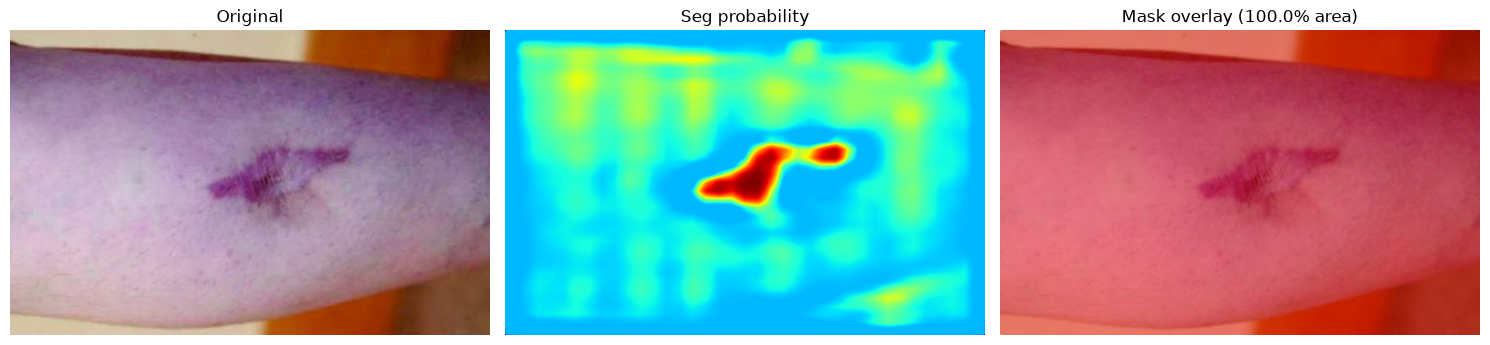

In [62]:
# ============================================================
# INFERENCE: one image through the verified WILLIEModel
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from pathlib import Path
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# --- Input size: model interpolates to 518 internally ---
# We feed 518 directly to avoid double interpolation.
INPUT_SIZE = 518

# --- Standard ImageNet normalization (DINOv2 convention) ---
preprocess = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def run_willie(image_path, model, device):
    """
    Run WILLIEModel on one image.
    Returns the 6 raw outputs + original RGB image for visualization.
    """
    # OpenCV loads BGR — convert to RGB for PIL/torchvision
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Preprocess → [1, 3, 518, 518] on device
    tensor = preprocess(Image.fromarray(img_rgb)).unsqueeze(0).to(device)

    # Forward pass — no gradient (inference only)
    with torch.no_grad():
        out = model(tensor)  # returns dict with 6 keys

    return out, img_rgb


# ------------------------------------------------------------
# FIX: Resolve image path robustly.
# Jupyter's CWD is usually the project root, but sometimes notebooks/.
# We search a few common locations and report exactly where it looks.
# ------------------------------------------------------------
CANDIDATES = [
    Path.cwd() / "sample_wound.jpg",                       # current dir
    Path.cwd().parent / "sample_wound.jpg",                # parent (if in notebooks/)
    Path(r"c:\rabies_experiment_and_system_implementation\sample_wound.jpg"),
]

IMAGE_PATH = None
for c in CANDIDATES:
    print(f"Checking: {c}  ->  exists={c.exists()}")
    if c.exists():
        IMAGE_PATH = c
        break

if IMAGE_PATH is None:
    raise FileNotFoundError(
        "sample_wound.jpg not found in any checked location.\n"
        "Save the image to one of these paths, then re-run:\n"
        + "\n".join(f"  {c}" for c in CANDIDATES)
    )

print(f"\n✅ Using image: {IMAGE_PATH}\n")

# --- Run inference ---
out, img_rgb = run_willie(IMAGE_PATH, model, device)

# --- Inspect the 6 outputs ---
print("Output keys and shapes:")
for k, v in out.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: shape={tuple(v.shape)}, "
              f"min={v.min().item():.3f}, max={v.max().item():.3f}")

# --- Classification: softmax over 5 classes ---
# Class names from WILLIE README: diabetic, pressure, surgical, venous, no_wound
CLASSES = ["diabetic", "pressure", "surgical", "venous", "no_wound"]
probs = F.softmax(out["cls_logits"], dim=1)[0].cpu().numpy()
pred = int(probs.argmax())

print(f"\nClassification: {CLASSES[pred]}  ({probs[pred]:.3f})")
for name, p in zip(CLASSES, probs):
    print(f"  {name:10s}: {p:.4f}")

# --- Segmentation: sigmoid → binary mask at 0.5 ---
seg_logits = out["seg_mask"]               # [1, 1, 518, 518]
seg_prob = torch.sigmoid(seg_logits)[0, 0].cpu().numpy()
seg_bin = (seg_prob > 0.5).astype(np.uint8)
wound_pct = seg_bin.sum() / seg_bin.size * 100

print(f"\nSegmentation: wound covers {wound_pct:.2f}% of image")

# --- Detection: objectness map — where is the peak? ---
obj = out["det_objectness"][0, 0].cpu().numpy()   # [37, 37]
peak = np.unravel_index(obj.argmax(), obj.shape)
print(f"Detection: peak objectness {obj.max():.3f} at grid {peak} (of 37x37)")

# --- Visualize ---
h, w = img_rgb.shape[:2]

seg_prob_resized = cv2.resize(seg_prob, (w, h), interpolation=cv2.INTER_LINEAR)
seg_bin_resized = cv2.resize(seg_bin, (w, h), interpolation=cv2.INTER_NEAREST)

overlay = img_rgb.copy()
overlay[seg_bin_resized == 1] = [255, 0, 0]
blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(seg_prob_resized, cmap="jet")
ax[1].set_title("Seg probability"); ax[1].axis("off")
ax[2].imshow(blended)
ax[2].set_title(f"Mask overlay ({wound_pct:.1f}% area)")
ax[2].axis("off")
plt.tight_layout(); plt.show()

In [63]:
# ============================================================
# THRESHOLD SWEEP — find where binarization separates wound from skin
# ============================================================
for t in [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]:
    seg_bin = (seg_prob > t).astype(np.uint8)
    pct = seg_bin.sum() / seg_bin.size * 100
    print(f"Threshold {t:.2f}: wound covers {pct:6.2f}%  "
          f"({'plausible' if 1 < pct < 30 else 'too much/too little'})")

Threshold 0.50: wound covers  99.99%  (too much/too little)
Threshold 0.70: wound covers   3.65%  (plausible)
Threshold 0.80: wound covers   2.04%  (plausible)
Threshold 0.90: wound covers   1.27%  (plausible)
Threshold 0.95: wound covers   0.50%  (too much/too little)
Threshold 0.99: wound covers   0.00%  (too much/too little)


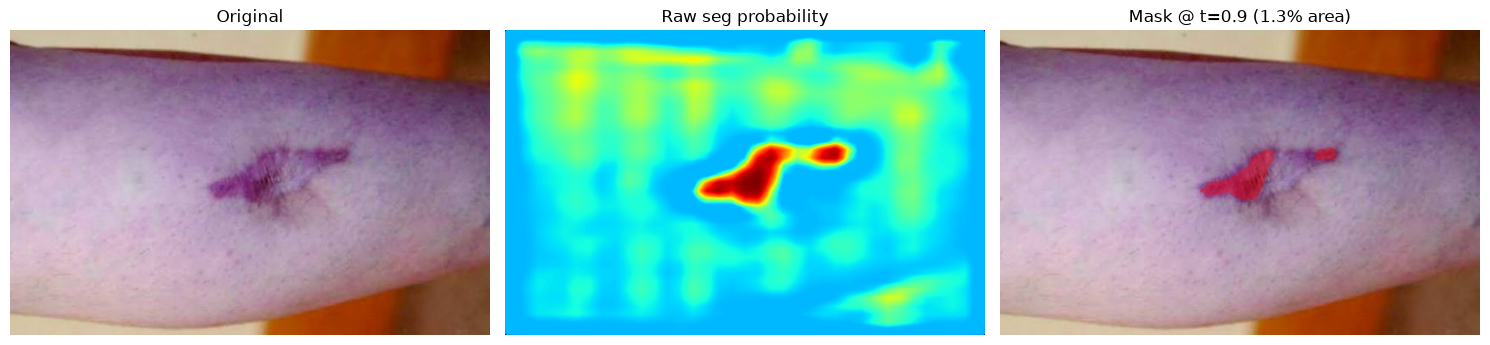

In [64]:
# ============================================================
# VISUALIZE WITH ADAPTIVE THRESHOLD
# ============================================================
BEST_T = 0.90  # <-- replace with whatever the sweep shows

seg_bin = (seg_prob > BEST_T).astype(np.uint8)
wound_pct = seg_bin.sum() / seg_bin.size * 100

h, w = img_rgb.shape[:2]
seg_prob_resized = cv2.resize(seg_prob, (w, h), interpolation=cv2.INTER_LINEAR)
seg_bin_resized = cv2.resize(seg_bin, (w, h), interpolation=cv2.INTER_NEAREST)

overlay = img_rgb.copy()
overlay[seg_bin_resized == 1] = [255, 0, 0]
blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(seg_prob_resized, cmap="jet")
ax[1].set_title("Raw seg probability"); ax[1].axis("off")
ax[2].imshow(blended)
ax[2].set_title(f"Mask @ t={BEST_T} ({wound_pct:.1f}% area)")
ax[2].axis("off")
plt.tight_layout(); plt.show()

In [66]:
# ============================================================
# ADAPTIVE THRESHOLD — works across different images
# ============================================================
# Idea: the wound is the top-N% of probability. Pick N based on
# how peaked the map is, not on an absolute value.

def adaptive_mask(prob, top_percent=5.0):
    """
    Keep only the top `top_percent` of probability mass.
    Robust to baseline shifts across different skin/lighting.
    """
    flat = prob.flatten()
    cutoff = np.percentile(flat, 100 - top_percent)
    return (prob >= cutoff).astype(np.uint8), cutoff

# Try a few values to see stability
for pct in [1, 3, 5, 10]:
    m, cut = adaptive_mask(seg_prob, top_percent=pct)
    area = m.sum() / m.size * 100
    print(f"top {pct:>2}%  -> cutoff={cut:.3f}, wound covers {area:.2f}%")

top  1%  -> cutoff=0.924, wound covers 1.00%
top  3%  -> cutoff=0.714, wound covers 3.00%
top  5%  -> cutoff=0.684, wound covers 5.00%
top 10%  -> cutoff=0.654, wound covers 10.00%


In [67]:
def compute_dice(pred_mask, gt_mask, smooth=1e-6):
    """
    Dice Similarity Coefficient.
    Range 0-1. Higher is better.
    Formula: 2 * |pred ∩ gt| / (|pred| + |gt|)
    """
    pred_flat = pred_mask.flatten()
    gt_flat = gt_mask.flatten()
    intersection = (pred_flat * gt_flat).sum()
    return (2. * intersection + smooth) / (pred_flat.sum() + gt_flat.sum() + smooth)

def compute_iou(pred_mask, gt_mask, smooth=1e-6):
    """
    Intersection over Union (Jaccard Index).
    Range 0-1. Higher is better.
    Formula: |pred ∩ gt| / |pred ∪ gt|
    """
    pred_flat = pred_mask.flatten()
    gt_flat = gt_mask.flatten()
    intersection = (pred_flat * gt_flat).sum()
    union = pred_flat.sum() + gt_flat.sum() - intersection
    return (intersection + smooth) / (union + smooth)

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_classification_metrics(y_true, y_pred):
    """
    Standard classification metrics.
    y_true, y_pred: lists of class labels (0-4)
    """
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

In [70]:
# ============================================================
# STEP 1: DOWNLOAD FUSEG DATASET
# ============================================================
# FUSeg has 1,210 foot ulcer images with expert masks.
# Split: 810 train, 200 validation, 200 test.
# Source: github.com/uwm-bigdata/wound-segmentation

import os
import subprocess

REPO_URL = "https://github.com/uwm-bigdata/wound-segmentation.git"
DATA_DIR = "wound_datasets"
os.makedirs(DATA_DIR, exist_ok=True)

repo_path = os.path.join(DATA_DIR, "wound-segmentation")

if not os.path.exists(repo_path):
    print("Cloning FUSeg repo (may take a few minutes)...")
    subprocess.run(["git", "clone", REPO_URL, repo_path], check=True)
    print("✅ Cloned.")
else:
    print("Repo already present.")

# --- Look at what we actually got ---
for root, dirs, files in os.walk(repo_path):
    # Only show directories at reasonable depth
    depth = root.replace(repo_path, "").count(os.sep)
    if depth <= 2:
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

Cloning FUSeg repo (may take a few minutes)...


✅ Cloned.
wound-segmentation/  (6 files)
  .git/  (5 files)
    hooks/  (14 files)
    info/  (1 files)
    logs/  (1 files)
    objects/  (0 files)
    refs/  (0 files)
  data/  (0 files)
    Foot Ulcer Segmentation Challenge/  (2 files)
    Medetec_foot_ulcer_224/  (0 files)
    wound_dataset/  (1 files)
  figures/  (1 files)
  models/  (4 files)
    __pycache__/  (4 files)
  training_history/  (1 files)
  utils/  (4 files)
    config/  (2 files)
    io/  (4 files)
    learning/  (3 files)
    postprocessing/  (3 files)
    preprocessing/  (2 files)
    __pycache__/  (2 files)


In [72]:
# ============================================================
# CHECK FOR MASKS — we need ground truth to compute Dice/IoU
# ============================================================
from pathlib import Path

REPO = Path("wound_datasets/wound-segmentation")
FUSEG = REPO / "data" / "Foot Ulcer Segmentation Challenge"

# --- Show the full directory tree under FUSeg (all depths) ---
print("=" * 60)
print("FULL FUSEG DIRECTORY TREE")
print("=" * 60)

for root, dirs, files in os.walk(FUSEG):
    # Skip hidden dirs
    dirs[:] = [d for d in dirs if not d.startswith(".")]
    rel = Path(root).relative_to(FUSEG)
    depth = len(rel.parts)
    indent = "  " * depth
    print(f"{indent}{Path(root).name}/  ({len(files)} files)")

# --- Counts and examples per folder ---
print("\n" + "=" * 60)
print("FOLDER SUMMARY")
print("=" * 60)

for sub in ["train", "test", "val", "validation"]:
    sub_path = FUSEG / sub
    if not sub_path.exists():
        continue
    print(f"\n{sub}/")
    for inner in sub_path.iterdir():
        if inner.is_dir():
            files = list(inner.glob("*"))
            print(f"  {inner.name}/  ({len(files)} files)")
            if files:
                print(f"    example: {files[0].name}")

FULL FUSEG DIRECTORY TREE
Foot Ulcer Segmentation Challenge/  (2 files)
  test/  (0 files)
    images/  (200 files)
  train/  (0 files)
    images/  (810 files)
    labels/  (810 files)
  validation/  (0 files)
    images/  (200 files)
    labels/  (200 files)

FOLDER SUMMARY

train/
  images/  (810 files)
    example: 0011.png
  labels/  (810 files)
    example: 0011.png

test/
  images/  (200 files)
    example: 1011.png

validation/
  images/  (200 files)
    example: 0001.png
  labels/  (200 files)
    example: 0001.png


In [73]:
# ============================================================
# CELL 1: BUILD EVALUATION DATASET FROM FUSEG VALIDATION SPLIT
# ============================================================
from pathlib import Path

REPO = Path("wound_datasets/wound-segmentation")
FUSEG = REPO / "data" / "Foot Ulcer Segmentation Challenge"
VAL_IMAGES = FUSEG / "validation" / "images"
VAL_LABELS = FUSEG / "validation" / "labels"

# Pair each image with its matching label (same filename, different folder)
dataset = []
for img_path in sorted(VAL_IMAGES.glob("*.png")):
    mask_path = VAL_LABELS / img_path.name
    if mask_path.exists():
        dataset.append((str(img_path), str(mask_path)))

print(f"Found {len(dataset)} image-mask pairs in validation set.")
print("\nFirst 3 pairs:")
for img, mask in dataset[:3]:
    print(f"  img:  {img}")
    print(f"  mask: {mask}")

assert len(dataset) > 0, "No pairs found — check paths."

Found 200 image-mask pairs in validation set.

First 3 pairs:
  img:  wound_datasets\wound-segmentation\data\Foot Ulcer Segmentation Challenge\validation\images\0001.png
  mask: wound_datasets\wound-segmentation\data\Foot Ulcer Segmentation Challenge\validation\labels\0001.png
  img:  wound_datasets\wound-segmentation\data\Foot Ulcer Segmentation Challenge\validation\images\0002.png
  mask: wound_datasets\wound-segmentation\data\Foot Ulcer Segmentation Challenge\validation\labels\0002.png
  img:  wound_datasets\wound-segmentation\data\Foot Ulcer Segmentation Challenge\validation\images\0003.png
  mask: wound_datasets\wound-segmentation\data\Foot Ulcer Segmentation Challenge\validation\labels\0003.png


In [74]:
# ============================================================
# CELL 2: SEGMENTATION METRICS (Dice, IoU)
# ============================================================
import numpy as np

def compute_dice(pred, gt, smooth=1e-6):
    """
    Dice Similarity Coefficient.
    Range 0-1. Higher is better.
    Formula: 2 * |pred ∩ gt| / (|pred| + |gt|)
    """
    pred_flat = pred.flatten().astype(np.float32)
    gt_flat = gt.flatten().astype(np.float32)
    inter = (pred_flat * gt_flat).sum()
    return (2. * inter + smooth) / (pred_flat.sum() + gt_flat.sum() + smooth)


def compute_iou(pred, gt, smooth=1e-6):
    """
    Intersection over Union (Jaccard Index).
    Range 0-1. Higher is better.
    Formula: |pred ∩ gt| / |pred ∪ gt|
    """
    pred_flat = pred.flatten().astype(np.float32)
    gt_flat = gt.flatten().astype(np.float32)
    inter = (pred_flat * gt_flat).sum()
    union = pred_flat.sum() + gt_flat.sum() - inter
    return (inter + smooth) / (union + smooth)


def adaptive_mask(prob, top_percent=5.0):
    """
    Keep only the top N% of probability mass.
    Robust to baseline shifts across images.
    """
    cutoff = np.percentile(prob.flatten(), 100 - top_percent)
    return (prob >= cutoff).astype(np.uint8)


# Sanity check — perfect prediction should give Dice=1.0, IoU=1.0
fake_gt = np.array([[1, 1], [0, 0]], dtype=np.uint8)
assert abs(compute_dice(fake_gt, fake_gt) - 1.0) < 1e-5
assert abs(compute_iou(fake_gt, fake_gt) - 1.0) < 1e-5
print("✅ Metric functions OK")

✅ Metric functions OK


In [76]:
# ============================================================
# CELL 3: EVALUATE WILLIE ON FUSEG VALIDATION SET
# ============================================================
# For each image:
#   1. Run WILLIE → seg_prob at 518×518
#   2. Resize to original image size (to match GT dimensions)
#   3. Build predicted mask two ways:
#        (a) fixed threshold 0.5
#        (b) adaptive threshold (top 5%)
#   4. Compute Dice & IoU against ground truth for both
#
# We report both so we can see which strategy is actually better.

import cv2
import torch
import torch.nn.functional as F

# Storage
results = {
    "dice_fixed":     [],
    "iou_fixed":      [],
    "dice_adaptive":  [],
    "iou_adaptive":   [],
    "gt_area_pct":    [],
    "pred_area_fixed_pct":    [],
    "pred_area_adaptive_pct": [],
}

MAX_IMAGES = 200  # full validation set

print(f"Evaluating on {MAX_IMAGES} images...\n")

for i, (img_path, mask_path) in enumerate(dataset[:MAX_IMAGES]):
    try:
        # --- 1. Run WILLIE ---
        out, img_rgb = run_willie(img_path, model, device)

        # --- 2. Get segmentation probability at model resolution (518×518) ---
        seg_prob = torch.sigmoid(out["seg_mask"])[0, 0].cpu().numpy()

        # --- 3. Load ground-truth mask at ORIGINAL resolution ---
        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if gt_mask is None:
            print(f"[{i}] Skip: cannot read {mask_path}")
            continue
        gt_h, gt_w = gt_mask.shape
        gt_bin = (gt_mask > 128).astype(np.uint8)

        # --- 4. Resize prediction to ORIGINAL resolution (match GT) ---
        pred_prob = cv2.resize(seg_prob, (gt_w, gt_h), interpolation=cv2.INTER_LINEAR)

        # --- 5. Two binarization strategies ---
        pred_fixed = (pred_prob > 0.5).astype(np.uint8)
        pred_adaptive = adaptive_mask(pred_prob, top_percent=5.0)

        # --- 6. Metrics ---
        results["dice_fixed"].append(compute_dice(pred_fixed, gt_bin))
        results["iou_fixed"].append(compute_iou(pred_fixed, gt_bin))
        results["dice_adaptive"].append(compute_dice(pred_adaptive, gt_bin))
        results["iou_adaptive"].append(compute_iou(pred_adaptive, gt_bin))

        results["gt_area_pct"].append(gt_bin.sum() / gt_bin.size * 100)
        results["pred_area_fixed_pct"].append(pred_fixed.sum() / pred_fixed.size * 100)
        results["pred_area_adaptive_pct"].append(pred_adaptive.sum() / pred_adaptive.size * 100)

        if (i + 1) % 20 == 0:
            print(f"[{i+1}/{MAX_IMAGES}] "
                  f"Dice(fixed)={np.mean(results['dice_fixed']):.4f}  "
                  f"Dice(adaptive)={np.mean(results['dice_adaptive']):.4f}")

    except Exception as e:
        print(f"[{i}] Error: {e}")
        continue

print("\n✅ Evaluation complete.")

Evaluating on 200 images...

[20/200] Dice(fixed)=0.8532  Dice(adaptive)=0.3340
[40/200] Dice(fixed)=0.8181  Dice(adaptive)=0.2713
[60/200] Dice(fixed)=0.8197  Dice(adaptive)=0.2669
[80/200] Dice(fixed)=0.8198  Dice(adaptive)=0.2904
[100/200] Dice(fixed)=0.8104  Dice(adaptive)=0.2884
[120/200] Dice(fixed)=0.8015  Dice(adaptive)=0.2973
[140/200] Dice(fixed)=0.8043  Dice(adaptive)=0.3146
[160/200] Dice(fixed)=0.8015  Dice(adaptive)=0.3167
[180/200] Dice(fixed)=0.7941  Dice(adaptive)=0.3116
[200/200] Dice(fixed)=0.7904  Dice(adaptive)=0.3111

✅ Evaluation complete.


In [77]:
# ============================================================
# CELL 4: REPORT RESULTS
# ============================================================
print("=" * 65)
print("WILLIE ON FUSEG VALIDATION (n = {})".format(len(results["dice_fixed"])))
print("=" * 65)

def report(name, values):
    arr = np.array(values)
    print(f"{name:30s} {arr.mean():.4f} ± {arr.std():.4f}   "
          f"(min={arr.min():.4f}, max={arr.max():.4f})")

print("\n--- Segmentation ---")
report("Dice (fixed t=0.5):",     results["dice_fixed"])
report("IoU  (fixed t=0.5):",     results["iou_fixed"])
report("Dice (adaptive top 5%):", results["dice_adaptive"])
report("IoU  (adaptive top 5%):", results["iou_adaptive"])

print("\n--- Areas (as % of image) ---")
report("GT wound area:",          results["gt_area_pct"])
report("Pred area (fixed):",      results["pred_area_fixed_pct"])
report("Pred area (adaptive):",   results["pred_area_adaptive_pct"])

print("\n--- Comparison to published WILLIE result ---")
print("Paper reports Dice = 91.41% on their chronic wound benchmark.")
print("We are testing on FUSeg (foot ulcers) — a different dataset.")
print("If our Dice is much lower, the domain gap is real.")

WILLIE ON FUSEG VALIDATION (n = 200)

--- Segmentation ---
Dice (fixed t=0.5):            0.7904 ± 0.2210   (min=0.0000, max=1.0000)
IoU  (fixed t=0.5):            0.6941 ± 0.2269   (min=0.0000, max=1.0000)
Dice (adaptive top 5%):        0.3111 ± 0.2612   (min=0.0000, max=0.9605)
IoU  (adaptive top 5%):        0.2191 ± 0.2291   (min=0.0000, max=0.9239)

--- Areas (as % of image) ---
GT wound area:                 1.2224 ± 1.5020   (min=0.0000, max=7.6920)
Pred area (fixed):             1.1841 ± 1.4648   (min=0.0000, max=7.5912)
Pred area (adaptive):          5.0003 ± 0.0001   (min=5.0003, max=5.0007)

--- Comparison to published WILLIE result ---
Paper reports Dice = 91.41% on their chronic wound benchmark.
We are testing on FUSeg (foot ulcers) — a different dataset.
If our Dice is much lower, the domain gap is real.


✅ Saved: willie_evaluation_dashboard.png


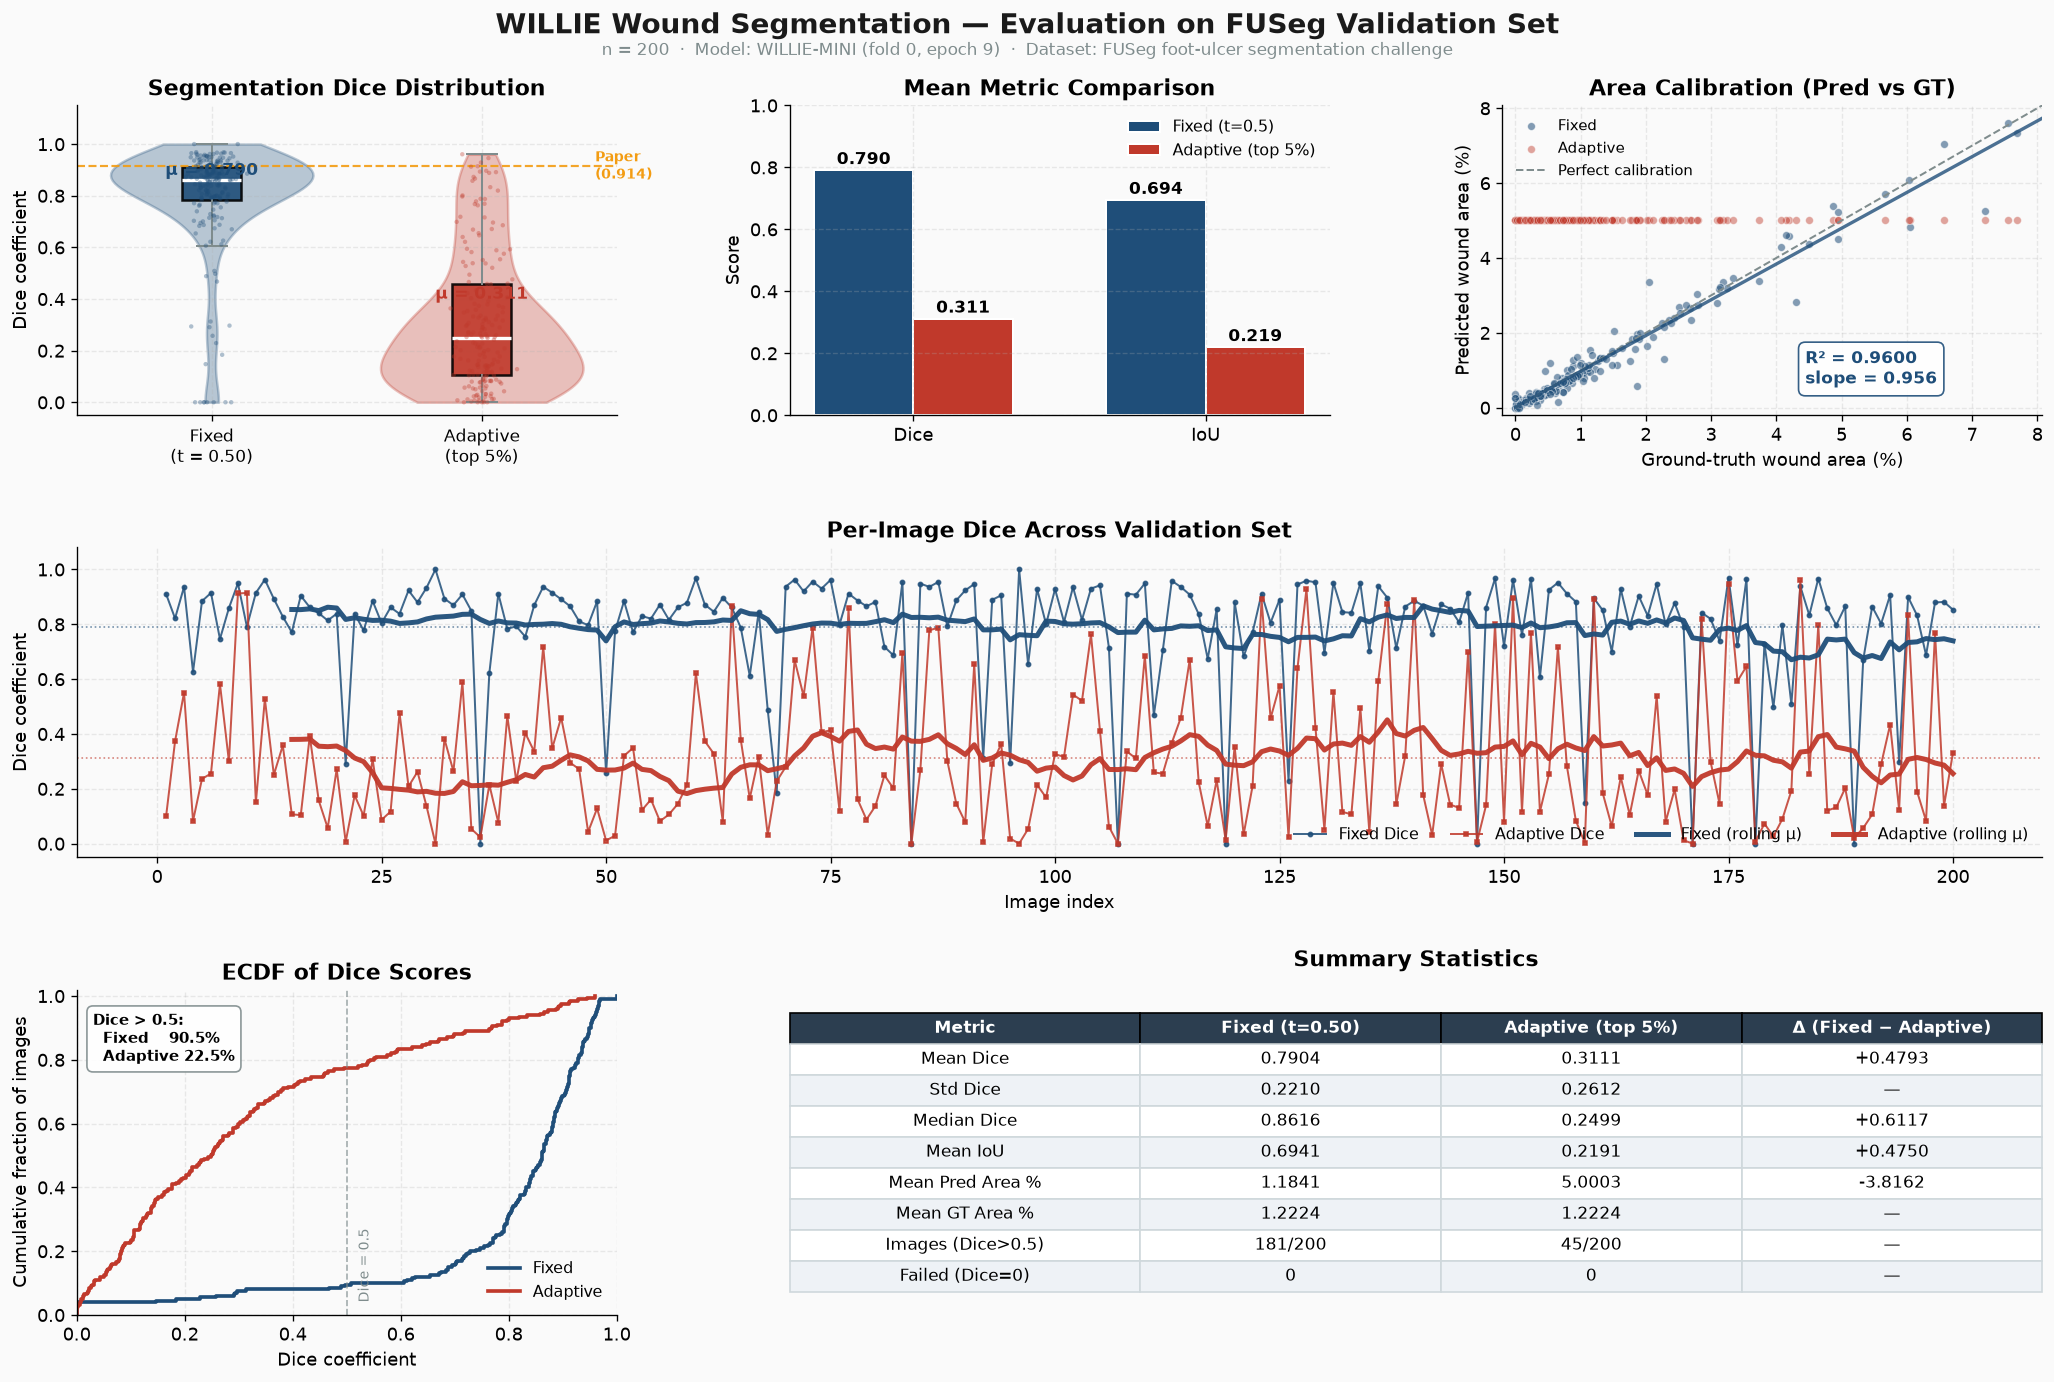

In [79]:
# ============================================================
# PROFESSIONAL EVALUATION DASHBOARD
# ============================================================
# Requires: the `results` dict from the evaluation loop
# Output: a single high-res figure with 6 panels + summary stats
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
from scipy import stats
import cv2
import torch
import torch.nn.functional as F

# --- Global style ---
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":        True,
    "grid.alpha":       0.25,
    "grid.linestyle":   "--",
    "figure.dpi":       120,
})

# --- Colour palette ---
C_FIXED     = "#1f4e79"   # deep blue
C_ADAPTIVE  = "#c0392b"   # brick red
C_GT        = "#27ae60"   # green
C_ACCENT    = "#f39c12"   # amber
C_MUTED     = "#7f8c8d"   # grey
C_BG        = "#fafafa"

# --- Pull metrics from results dict ---
d_fix  = np.array(results["dice_fixed"])
i_fix  = np.array(results["iou_fixed"])
d_ada  = np.array(results["dice_adaptive"])
i_ada  = np.array(results["iou_adaptive"])
gt_a   = np.array(results["gt_area_pct"])
pf_a   = np.array(results["pred_area_fixed_pct"])
pa_a   = np.array(results["pred_area_adaptive_pct"])

N = len(d_fix)

# ============================================================
# FIGURE LAYOUT
# ============================================================
fig = plt.figure(figsize=(18, 12), facecolor=C_BG)
gs = GridSpec(
    3, 3, figure=fig,
    height_ratios=[1.0, 1.0, 1.05],
    hspace=0.42, wspace=0.32,
    left=0.06, right=0.97, top=0.90, bottom=0.06,
)

# --- Suptitle ---
fig.suptitle(
    "WILLIE Wound Segmentation — Evaluation on FUSeg Validation Set",
    fontsize=17, fontweight="bold", color="#1a1a1a", y=0.965,
)
fig.text(
    0.5, 0.935,
    f"n = {N}  ·  Model: WILLIE-MINI (fold 0, epoch 9)  ·  "
    f"Dataset: FUSeg foot-ulcer segmentation challenge",
    ha="center", fontsize=10, color=C_MUTED,
)

# ============================================================
# PANEL 1 — Dice distribution (violin + box + jitter)
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(C_BG)

data_v = [d_fix, d_ada]
labels = ["Fixed\n(t = 0.50)", "Adaptive\n(top 5%)"]
colors = [C_FIXED, C_ADAPTIVE]

parts = ax1.violinplot(
    data_v, positions=[1, 2], widths=0.75,
    showmeans=False, showmedians=False, showextrema=False,
)
for pc, col in zip(parts["bodies"], colors):
    pc.set_facecolor(col)
    pc.set_alpha(0.30)
    pc.set_edgecolor(col)
    pc.set_linewidth(1.5)

bp = ax1.boxplot(
    data_v, positions=[1, 2], widths=0.22,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color=C_MUTED, linewidth=1.2),
    capprops=dict(color=C_MUTED, linewidth=1.2),
    boxprops=dict(linewidth=1.5),
)
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.9)

# Jittered scatter
rng = np.random.default_rng(42)
for pos, arr, col in zip([1, 2], data_v, colors):
    jx = pos + rng.normal(0, 0.045, len(arr))
    ax1.scatter(jx, arr, s=7, color=col, alpha=0.35, edgecolor="none", zorder=3)

# Mean annotations
for pos, arr, col in zip([1, 2], data_v, colors):
    ax1.text(pos, arr.mean() + 0.09, f"μ = {arr.mean():.3f}",
             ha="center", fontsize=10, fontweight="bold", color=col)

ax1.set_xticks([1, 2])
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylabel("Dice coefficient")
ax1.set_ylim(-0.05, 1.15)
ax1.set_title("Segmentation Dice Distribution")
ax1.axhline(0.9141, color=C_ACCENT, linestyle="--", linewidth=1.3, alpha=0.9)
ax1.text(2.42, 0.9141, "Paper\n(0.914)", fontsize=8.5, color=C_ACCENT,
         va="center", ha="left", fontweight="bold")

# ============================================================
# PANEL 2 — Grouped bar: mean metrics comparison
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(C_BG)

metrics = ["Dice", "IoU"]
fixed_means  = [d_fix.mean(),  i_fix.mean()]
adaptive_means = [d_ada.mean(), i_ada.mean()]

x = np.arange(len(metrics))
w = 0.34

b1 = ax2.bar(x - w/2, fixed_means,    w, label="Fixed (t=0.5)",
             color=C_FIXED, edgecolor="white", linewidth=1.2)
b2 = ax2.bar(x + w/2, adaptive_means, w, label="Adaptive (top 5%)",
             color=C_ADAPTIVE, edgecolor="white", linewidth=1.2)

# Value labels
for bars, vals in [(b1, fixed_means), (b2, adaptive_means)]:
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=11)
ax2.set_ylabel("Score")
ax2.set_ylim(0, 1.0)
ax2.set_title("Mean Metric Comparison")
ax2.legend(frameon=False, loc="upper right", fontsize=9.5)

# ============================================================
# PANEL 3 — Predicted vs GT area (calibration)
# ============================================================
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(C_BG)

ax3.scatter(gt_a, pf_a, s=22, color=C_FIXED, alpha=0.55,
            edgecolor="white", linewidth=0.5, label="Fixed")
ax3.scatter(gt_a, pa_a, s=22, color=C_ADAPTIVE, alpha=0.45,
            edgecolor="white", linewidth=0.5, label="Adaptive")

# y = x reference line
lim = max(gt_a.max(), pf_a.max(), pa_a.max()) * 1.05
ax3.plot([0, lim], [0, lim], linestyle="--", color=C_MUTED,
         linewidth=1.2, label="Perfect calibration")

# Regression on fixed
slope, intercept, r, _, _ = stats.linregress(gt_a, pf_a)
xs = np.linspace(0, lim, 100)
ax3.plot(xs, slope*xs + intercept, color=C_FIXED, linewidth=2, alpha=0.8)

ax3.text(0.55*lim, 0.08*lim,
         f"R² = {r**2:.4f}\nslope = {slope:.3f}",
         fontsize=10, fontweight="bold", color=C_FIXED,
         bbox=dict(boxstyle="round,pad=0.4", fc="white",
                   ec=C_FIXED, alpha=0.9))

ax3.set_xlabel("Ground-truth wound area (%)")
ax3.set_ylabel("Predicted wound area (%)")
ax3.set_title("Area Calibration (Pred vs GT)")
ax3.legend(frameon=False, fontsize=9, loc="upper left")
ax3.set_xlim(-0.2, lim)
ax3.set_ylim(-0.2, lim)

# ============================================================
# PANEL 4 — Per-image Dice trajectory
# ============================================================
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor(C_BG)

idx = np.arange(1, N + 1)
ax4.plot(idx, d_fix, color=C_FIXED, linewidth=1.2, alpha=0.85,
         marker="o", markersize=2.5, label="Fixed Dice")
ax4.plot(idx, d_ada, color=C_ADAPTIVE, linewidth=1.2, alpha=0.85,
         marker="s", markersize=2.5, label="Adaptive Dice")

# Rolling mean
def rolling(x, w=15):
    return np.convolve(x, np.ones(w)/w, mode="valid")

if N >= 15:
    rm_fix = rolling(d_fix); rm_ada = rolling(d_ada)
    ax4.plot(np.arange(15, N+1), rm_fix, color=C_FIXED, linewidth=3,
             alpha=0.95, label="Fixed (rolling μ)")
    ax4.plot(np.arange(15, N+1), rm_ada, color=C_ADAPTIVE, linewidth=3,
             alpha=0.95, label="Adaptive (rolling μ)")

ax4.axhline(d_fix.mean(), color=C_FIXED, linestyle=":", linewidth=1.0, alpha=0.6)
ax4.axhline(d_ada.mean(), color=C_ADAPTIVE, linestyle=":", linewidth=1.0, alpha=0.6)

ax4.set_xlabel("Image index")
ax4.set_ylabel("Dice coefficient")
ax4.set_ylim(-0.05, 1.08)
ax4.set_title("Per-Image Dice Across Validation Set")
ax4.legend(frameon=False, fontsize=9.5, ncol=4, loc="lower right")

# ============================================================
# PANEL 5 — Cumulative distribution (ECDF)
# ============================================================
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor(C_BG)

def ecdf(a):
    xs = np.sort(a)
    ys = np.arange(1, len(xs)+1) / len(xs)
    return xs, ys

xs_f, ys_f = ecdf(d_fix)
xs_a, ys_a = ecdf(d_ada)

ax5.step(xs_f, ys_f, where="post", color=C_FIXED, linewidth=2.2, label="Fixed")
ax5.step(xs_a, ys_a, where="post", color=C_ADAPTIVE, linewidth=2.2, label="Adaptive")

ax5.axvline(0.5, color=C_MUTED, linestyle="--", linewidth=1.0, alpha=0.7)
ax5.text(0.52, 0.05, "Dice = 0.5", color=C_MUTED, fontsize=8.5, rotation=90)

# Highlight fraction above threshold
frac_fix_50 = (d_fix > 0.5).mean()
frac_ada_50 = (d_ada > 0.5).mean()
ax5.text(0.03, 0.95,
         f"Dice > 0.5:\n  Fixed    {frac_fix_50*100:.1f}%\n  Adaptive {frac_ada_50*100:.1f}%",
         fontsize=9, va="top", fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=C_MUTED, alpha=0.9))

ax5.set_xlabel("Dice coefficient")
ax5.set_ylabel("Cumulative fraction of images")
ax5.set_title("ECDF of Dice Scores")
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1.02)
ax5.legend(frameon=False, fontsize=9.5, loc="lower right")

# ============================================================
# PANEL 6 — Summary statistics table
# ============================================================
ax6 = fig.add_subplot(gs[2, 1:])
ax6.axis("off")

def fmt(v, n=4):
    return f"{v:.{n}f}"

table_rows = [
    ["Metric",            "Fixed (t=0.50)",       "Adaptive (top 5%)",      "Δ (Fixed − Adaptive)"],
    ["Mean Dice",         fmt(d_fix.mean()),      fmt(d_ada.mean()),        f"+{d_fix.mean()-d_ada.mean():.4f}"],
    ["Std Dice",          fmt(d_fix.std()),       fmt(d_ada.std()),         "—"],
    ["Median Dice",       fmt(np.median(d_fix)),  fmt(np.median(d_ada)),    f"+{np.median(d_fix)-np.median(d_ada):.4f}"],
    ["Mean IoU",          fmt(i_fix.mean()),      fmt(i_ada.mean()),        f"+{i_fix.mean()-i_ada.mean():.4f}"],
    ["Mean Pred Area %",  fmt(pf_a.mean()),       fmt(pa_a.mean()),         f"{pf_a.mean()-pa_a.mean():+.4f}"],
    ["Mean GT Area %",    fmt(gt_a.mean()),       fmt(gt_a.mean()),         "—"],
    ["Images (Dice>0.5)", f"{(d_fix>0.5).sum()}/{N}", f"{(d_ada>0.5).sum()}/{N}", "—"],
    ["Failed (Dice=0)",   f"{(d_fix==0).sum()}",  f"{(d_ada==0).sum()}",    "—"],
]

tab = ax6.table(
    cellText=table_rows[1:],
    colLabels=table_rows[0],
    cellLoc="center", loc="center",
    colWidths=[0.28, 0.24, 0.24, 0.24],
)
tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1, 1.55)

# Style header
for j in range(len(table_rows[0])):
    c = tab[(0, j)]
    c.set_facecolor("#2c3e50")
    c.set_text_props(color="white", fontweight="bold")

# Style rows
for i in range(1, len(table_rows)):
    for j in range(len(table_rows[0])):
        c = tab[(i, j)]
        c.set_facecolor("white" if i % 2 else "#eef2f6")
        c.set_edgecolor("#cfd8dc")

ax6.set_title("Summary Statistics", fontsize=13, fontweight="bold", pad=14)

# ============================================================
# SAVE
# ============================================================
out_path = "willie_evaluation_dashboard.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor=C_BG)
print(f"✅ Saved: {out_path}")
plt.show()

✅ Saved: willie_failure_gallery.png


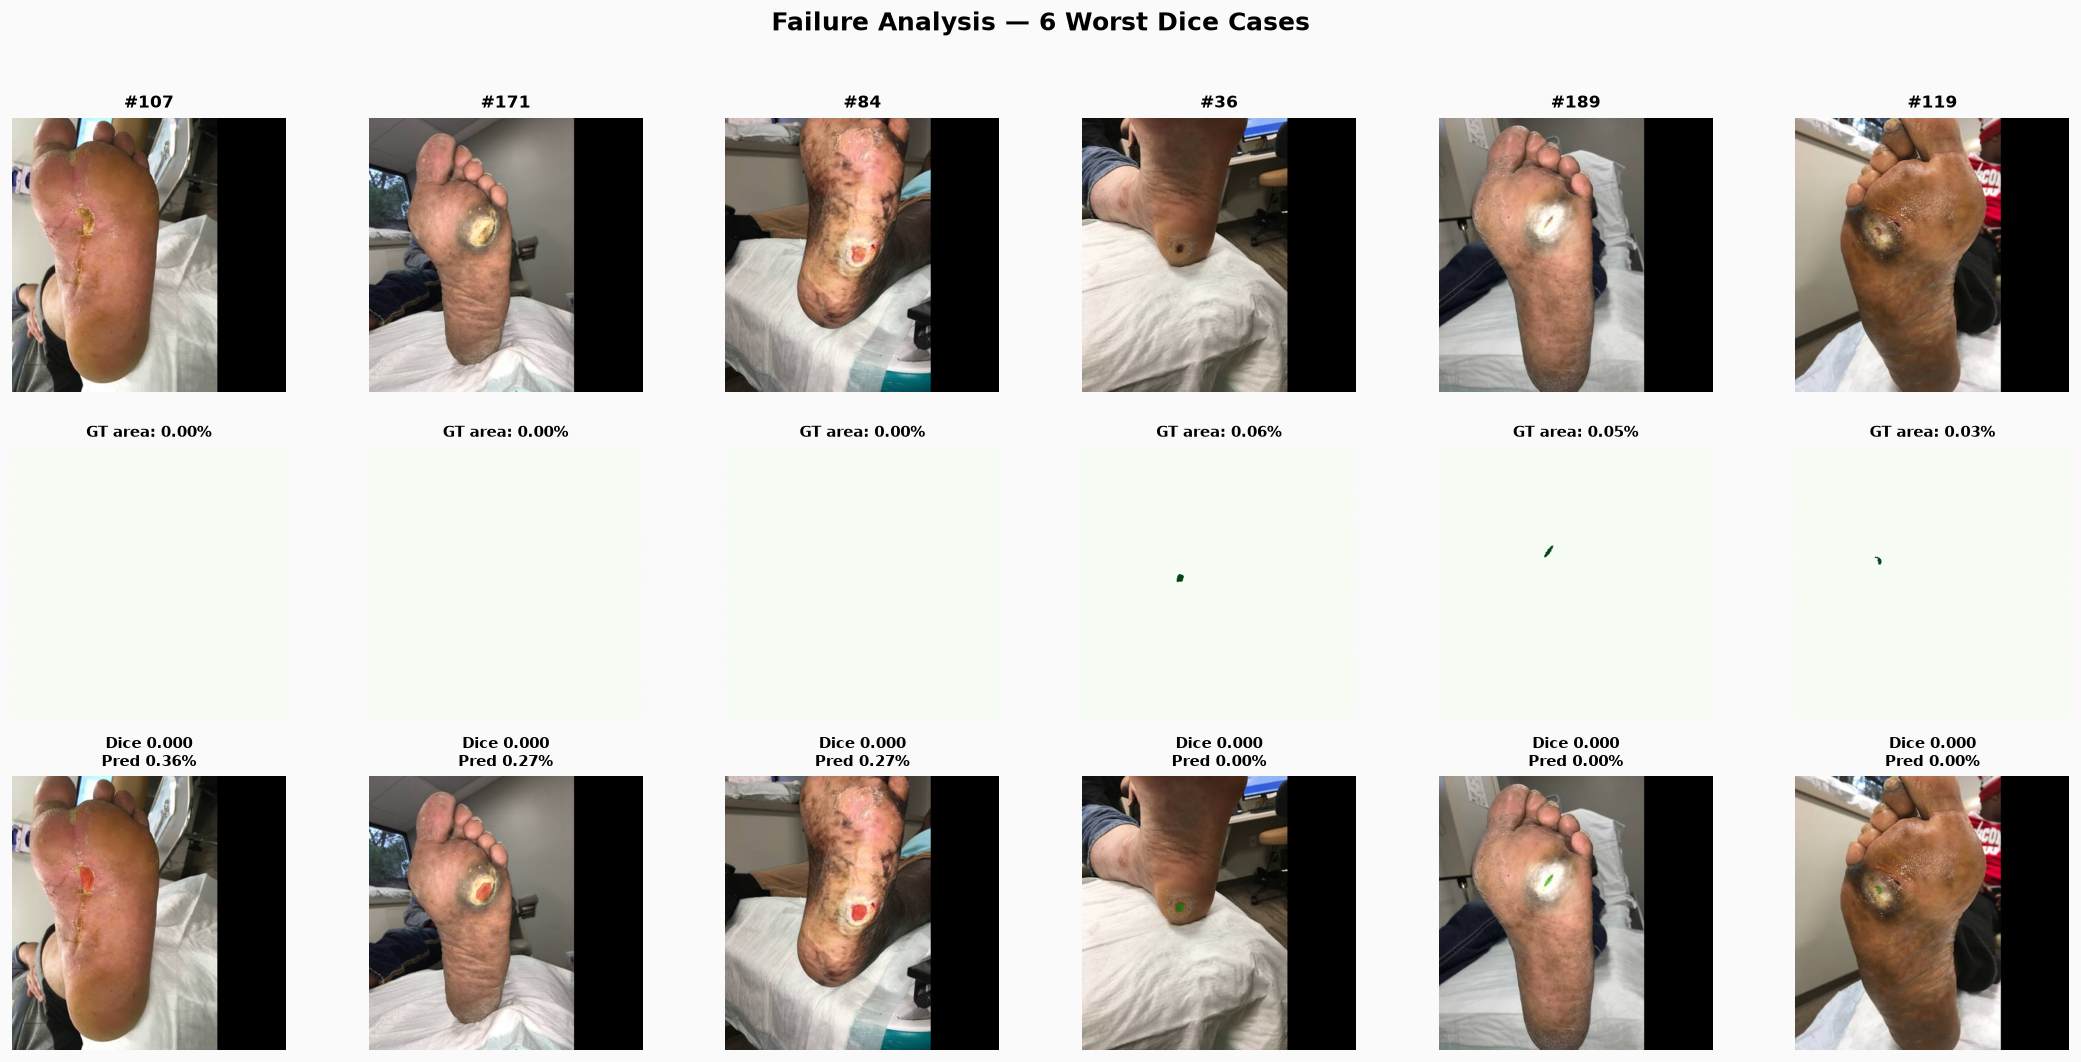

In [80]:
# ============================================================
# WORST-CASE GALLERY — 6 images where fixed Dice was lowest
# ============================================================
worst_idx = np.argsort(d_fix)[:6]

fig, axes = plt.subplots(3, 6, figsize=(18, 9), facecolor=C_BG)
fig.suptitle("Failure Analysis — 6 Worst Dice Cases",
             fontsize=15, fontweight="bold", y=0.98)

for col, i in enumerate(worst_idx):
    img_path, mask_path = dataset[i]

    # --- Run inference ---
    out, img_rgb = run_willie(img_path, model, device)
    seg_prob = torch.sigmoid(out["seg_mask"])[0, 0].cpu().numpy()

    # --- GT mask ---
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_h, gt_w = gt_mask.shape
    gt_bin = (gt_mask > 128).astype(np.uint8)

    # --- Prediction at original size ---
    pred_prob = cv2.resize(seg_prob, (gt_w, gt_h), interpolation=cv2.INTER_LINEAR)
    pred_bin = (pred_prob > 0.5).astype(np.uint8)

    # --- Overlay ---
    overlay = img_rgb.copy()
    overlay[gt_bin == 1] = [0, 200, 0]        # GT = green
    overlay[pred_bin == 1] = [220, 40, 40]    # Pred = red
    blended = cv2.addWeighted(img_rgb, 0.5, overlay, 0.5, 0)

    # --- Row 1: original ---
    axes[0, col].imshow(img_rgb)
    axes[0, col].set_title(f"#{i+1}", fontsize=10, fontweight="bold")
    axes[0, col].axis("off")

    # --- Row 2: GT mask ---
    axes[1, col].imshow(gt_bin, cmap="Greens")
    axes[1, col].set_title(f"GT area: {gt_a[i]:.2f}%", fontsize=9)
    axes[1, col].axis("off")

    # --- Row 3: prediction vs GT ---
    axes[2, col].imshow(blended)
    axes[2, col].set_title(
        f"Dice {d_fix[i]:.3f}\nPred {pf_a[i]:.2f}%",
        fontsize=9,
    )
    axes[2, col].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("willie_failure_gallery.png", dpi=200,
            bbox_inches="tight", facecolor=C_BG)
print("✅ Saved: willie_failure_gallery.png")
plt.show()